
# Download and Plot SGPS Proton Flux Data

Download, read, and plot proton flux from SGPS L2 data.


Import modules



In [38]:
import os
import requests
import netCDF4 as nc
import xarray as xr
import numpy as np
import cftime
import matplotlib.pyplot as plt
from matplotlib import colors, gridspec
import matplotlib.dates as mdates

Download, read, and get relevant data from files



In [39]:
files = ["sci_sgps-l2-avg5m_g18_d20251108_v3-0-2.nc",
         "sci_sgps-l2-avg5m_g18_d20251109_v3-0-2.nc",
         "sci_sgps-l2-avg5m_g18_d20251110_v3-0-2.nc",
         "sci_sgps-l2-avg5m_g18_d20251111_v3-0-2.nc",
         "sci_sgps-l2-avg5m_g18_d20251112_v3-0-2.nc",
         "sci_sgps-l2-avg5m_g18_d20251113_v3-0-2.nc",
         "sci_sgps-l2-avg5m_g18_d20251114_v3-0-2.nc",
         "sci_sgps-l2-avg5m_g18_d20251115_v3-0-2.nc",
         "sci_sgps-l2-avg5m_g18_d20251116_v3-0-2.nc"]

url_path = "https://data.ngdc.noaa.gov/platforms/solar-space-observing-satellites/goes/goes18/l2/data/sgps-l2-avg5m/2025/11/"

proton_diff_flux_west = []
proton_diff_flux_east = []
proton_int_flux = []
time = []

for filename in files:
    # Download `filename` if it does not exist locally
    if not os.path.exists(filename):
        with open(filename, "wb") as f:
            r = requests.get(url_path + filename)
            f.write(r.content)

    # Load data from file
    sgps_data = nc.Dataset(filename)

    # Get flux data
    proton_diff_flux_west.append(sgps_data['AvgDiffProtonFlux'][:, 0, :])
    proton_diff_flux_east.append(sgps_data['AvgDiffProtonFlux'][:, 1, :])
    proton_int_flux.append(sgps_data['AvgIntProtonFlux'][:])

    # Get timestamps
    # Two different time variable names may have been used
    try:
        time.append(sgps_data['L2_SciData_TimeStamp'][:])
    except IndexError:
        time.append(sgps_data['time'][:])

# Convert list of arrays into single array
proton_diff_flux_west = np.ma.concatenate(proton_diff_flux_west)
proton_diff_flux_east = np.ma.concatenate(proton_diff_flux_east)
proton_int_flux = np.ma.concatenate(proton_int_flux)
time = np.ma.concatenate(time)

# replace zeros with nans
proton_diff_flux_west = np.where(proton_diff_flux_west < 1.e-12, np.nan, proton_diff_flux_west)
proton_diff_flux_east = np.where(proton_diff_flux_east < 1.e-12, np.nan, proton_diff_flux_east)
proton_int_flux = np.where(proton_int_flux < 1.e-12, np.nan, proton_int_flux)

# Convert J2000 time to python datetime
time = cftime.num2pydate(time[:], sgps_data['time'].units)

Plot SGPS flux



(3563,)


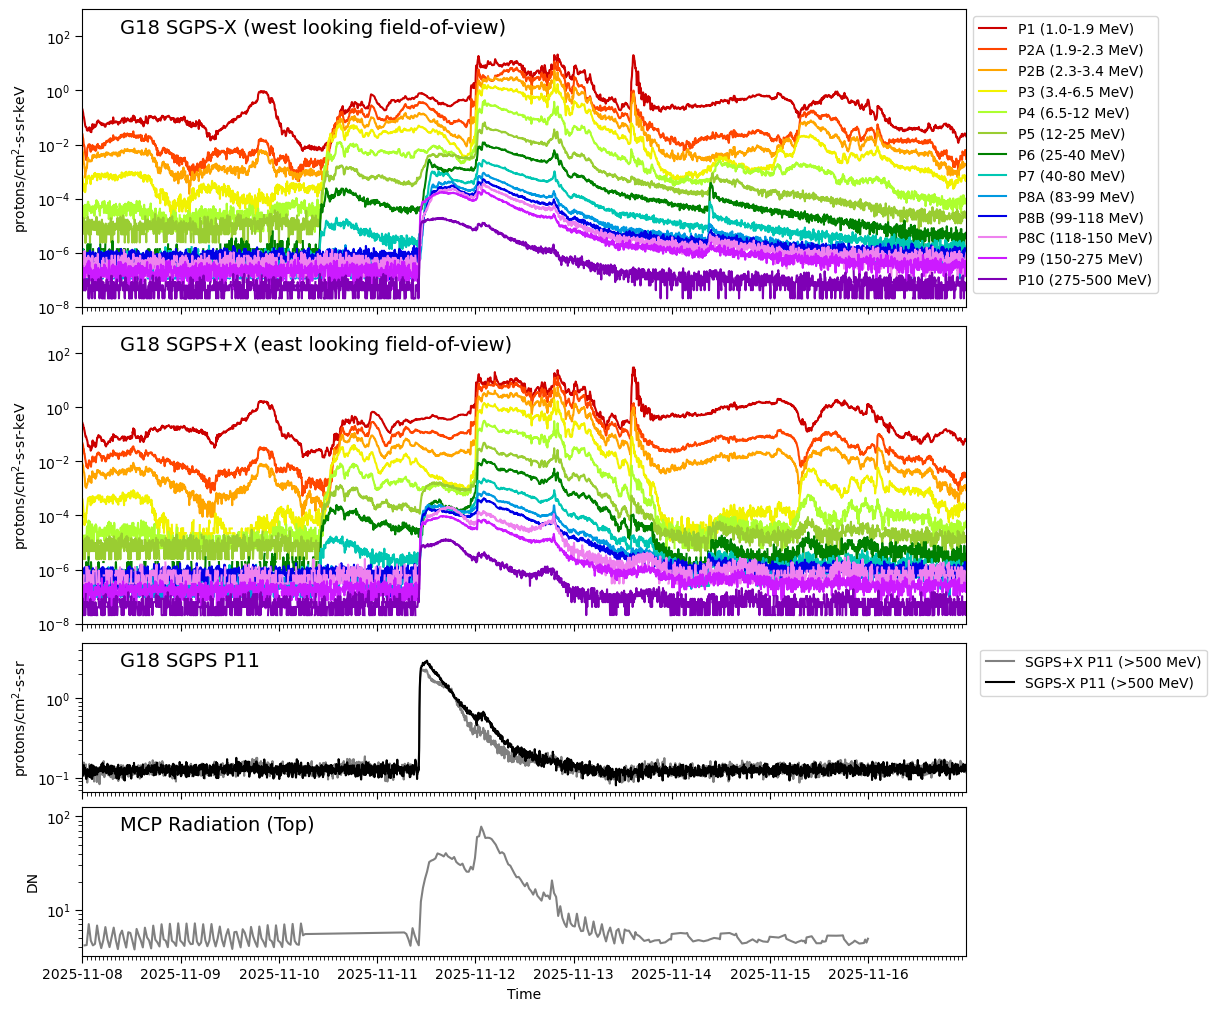

In [40]:
plt.figure(1, figsize=[12, 10], layout='constrained')
gridspec.GridSpec(6, 1)

# Plot differential flux
NUM_DIFF_CHANNELS = 13

chan_colors = [[.8, 0., 0.], colors.to_rgba('orangered')[0:3], colors.to_rgba('orange')[0:3],
               [.95, .95, .0], colors.to_rgba('greenyellow')[0:3], colors.to_rgba('yellowgreen')[0:3],
               colors.to_rgba('green')[0:3], [0., .78, .7], [0., .6, .88], [0., 0., .9],
               colors.to_rgba('violet')[0:3], [0.8, .1, 1.0], [0.49411765, 0., 0.70980392]]

chan_labels = ['P1 (1.0-1.9 MeV)', 'P2A (1.9-2.3 MeV)', 'P2B (2.3-3.4 MeV)', 'P3 (3.4-6.5 MeV)',
               'P4 (6.5-12 MeV)', 'P5 (12-25 MeV)', 'P6 (25-40 MeV)', 'P7 (40-80 MeV)',
               'P8A (83-99 MeV)', 'P8B (99-118 MeV)', 'P8C (118-150 MeV)', 'P9 (150-275 MeV)',
               'P10 (275-500 MeV)']

# SGPS-X (west)
ax1 = plt.subplot2grid((6, 1), (0, 0), colspan=1, rowspan=2)
for i in range(NUM_DIFF_CHANNELS):
    plt.plot(time, proton_diff_flux_west[:, i], color=chan_colors[i], label=chan_labels[i])
textstr = 'G18 SGPS-X (west looking field-of-view)'
ax1.text(0.042, 0.97, textstr, transform=ax1.transAxes, fontsize=14, verticalalignment='top')
ax1.xaxis.set_minor_locator(mdates.HourLocator())
ax1.xaxis.set_major_locator(mdates.DayLocator())
ax1.tick_params(which = 'minor', length=3)
ax1.tick_params(which = 'major', length=5)
ax1.set_xlim(time[0], time[-1])
ax1.tick_params(labelbottom=False)
plt.yscale('log')
plt.ylim([1.e-8, 1.e3])
plt.ylabel('protons/cm$^2$-s-sr-keV')
ax1.legend(bbox_to_anchor=(1, 1.0))

# SGPS+X (east)
ax2 = plt.subplot2grid((6, 1), (2, 0), colspan=1, rowspan=2)
for i in range(NUM_DIFF_CHANNELS):
    plt.plot(time, proton_diff_flux_east[:, i], color=chan_colors[i], label=chan_labels[i])
textstr = 'G18 SGPS+X (east looking field-of-view)'
ax2.text(0.042, 0.97, textstr, transform=ax2.transAxes, fontsize=14, verticalalignment='top')
ax2.xaxis.set_minor_locator(mdates.HourLocator())
ax2.xaxis.set_major_locator(mdates.DayLocator())
ax2.tick_params(which = 'minor', length=3)
ax2.tick_params(which = 'major', length=5)
ax2.set_xlim(time[0], time[-1])
ax2.tick_params(labelbottom=False)
plt.yscale('log')
plt.ylim([1.e-8, 1.e3])
plt.ylabel('protons/cm$^2$-s-sr-keV')

# Plot integral flux
ax3 = plt.subplot2grid((6, 1), (4, 0), colspan=1, rowspan=1)
plt.plot(time, proton_int_flux[:, 1], color='grey', label='SGPS+X P11 (>500 MeV)')
plt.plot(time, proton_int_flux[:, 0], color='k', label='SGPS-X P11 (>500 MeV)')
textstr = 'G18 SGPS P11'
ax3.text(0.042, 0.94, textstr, transform=ax3.transAxes, fontsize=14, verticalalignment='top')
ax3.xaxis.set_minor_locator(mdates.HourLocator())
ax3.xaxis.set_major_locator(mdates.DayLocator())
#ax3.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
ax3.tick_params(which = 'minor', length=3)
ax3.tick_params(which = 'major', length=5)
ax3.set_xlim(time[0], time[-1])
ax3.tick_params(labelbottom=False)
#plt.xlabel('2026 (UT hours)')
plt.ylabel('protons/cm$^2$-s-sr')
plt.yscale('log')
ylims = ax3.get_ylim()
plt.ylim([ylims[0], 1.4*ylims[1]])

ax3.legend(bbox_to_anchor=(1.28, 1), prop={'size': 10})

# Plot MCP radiation

radiation_dataset = xr.open_dataset('products/radiation_data-top.nc')
start_datetime_str = "2025-11-08T00:00:00"
end_datetime_str = "2025-11-16T00:00:00"
n_frames_min = 0
mask_variant = "top"

start_index = 0
end_index = len(radiation_dataset["observation"])

start_datetime = np.datetime64(start_datetime_str)
end_datetime = np.datetime64(end_datetime_str)


mcp_rads = radiation_dataset["mcp_rad"].values
datetimes = radiation_dataset["observation"].values
n_frames = radiation_dataset["n_frames"].values
radiation_dataset.close()

datetimes = datetimes.astype('datetime64[ns]')
print(datetimes.shape)

#TODO: do this with masks, this is stupid

# find start index
for i, dt in enumerate(datetimes):
    #print(i, type(dt), type(start_datetime))
    if dt >= start_datetime:
        start_index = i
        break

mcp_rads = mcp_rads[start_index:]
datetimes = datetimes[start_index:]
n_frames = n_frames[start_index:]

# find end index
for i, dt in enumerate(datetimes):
    if dt > end_datetime:
        end_index = i
        break

mcp_rads = mcp_rads[:end_index]
datetimes = datetimes[:end_index]
n_frames = n_frames[:end_index]

for i, t_int in enumerate(n_frames):
    if t_int < n_frames_min:
        mcp_rads[i] = -1
        datetimes[i] = np.datetime64('NaT')

n_frames_mask = n_frames >= n_frames_min

# Apply mask
mcp_rads_filtered = mcp_rads[n_frames_mask]
datetimes_filtered = datetimes[n_frames_mask]


# Plot data
#fig, ax = plt.subplots()
#fig.set_size_inches((12, 4))
#ax.scatter(datetimes_filtered, mcp_rads_filtered, s=1, alpha=1, label='MCP Radiation')

#ax.set_xlabel('Time')
#ax.set_ylabel(f'Mean MCP Radiation (DN)')
#ax.set_title(f'MCP Radiation vs. Time\nSensor Region: {mask_variant.title()}  |  n_frames >= {n_frames_min}')
#ax.legend()



ax4 = plt.subplot2grid((6, 1), (5, 0), colspan=1, rowspan=1)
plt.plot(datetimes_filtered, mcp_rads_filtered, color='grey', label='MCP Radiation')
#plt.plot(time, proton_int_flux[:, 0], color='k', label='SGPS-X P11 (>500 MeV)')
textstr = 'MCP Radiation (Top)'
ax4.text(0.042, 0.94, textstr, transform=ax4.transAxes, fontsize=14, verticalalignment='top')
ax4.xaxis.set_minor_locator(mdates.HourLocator())
ax4.xaxis.set_major_locator(mdates.DayLocator())
#ax4.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
ax4.tick_params(which = 'minor', length=3)
ax4.tick_params(which = 'major', length=5)
ax4.set_xlim(time[0], time[-1])
plt.xlabel('Time')
plt.ylabel('DN')
plt.yscale('log')
ylims = ax4.get_ylim()
plt.ylim([ylims[0], 1.4*ylims[1]])




plt.show()